In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def loss(x, y, w):
    return np.sign(np.dot(x, w)) * y < 1.0

In [ ]:
data = []

with open("train.csv") as csv:
    while line := csv.readline():
        data.append(list(map(lambda x: x.strip(), line.split(";"))))

In [ ]:
w = np.array([0, -1], dtype="float")

graph_x, graph_y, colors = [], [], []

N = 100
S = 0.5

In [ ]:
for _ in range(N):
    q = 0
    for x1, x2, name in data:
        y = -1 if name == "caterpillar" else 1
        x = np.array([int(x1), int(x2)])

        if loss(x, y, w):
            w[0] += S * y
            q += 1

    if q == 0:
        break

In [ ]:
for x1, x2, _ in data:
    graph_x.append(int(x1))
    graph_y.append(int(x2))
    
    if w[0] * float(x1) + w[1] * float(x2) > 0:
        colors.append("red")
    else:
        colors.append("blue")

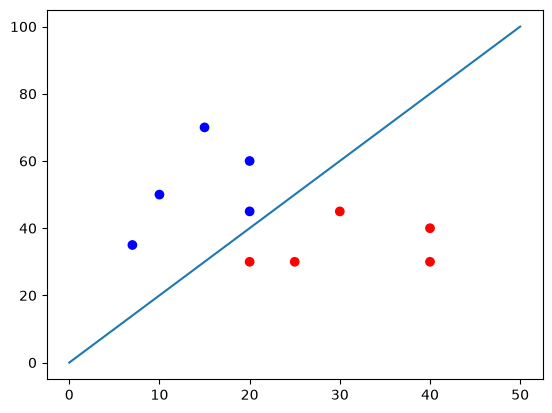

In [ ]:
plt.scatter(graph_x, graph_y, c=colors)

x = np.linspace(0, 50, 2)
y = -w[0] / w[1] * x
plt.plot(x, y)

Решение задачи бинарной классификации через МНК

In [ ]:
data = []

with open("train.csv") as csv:
    while line := csv.readline():
        data.append(list(map(lambda x: x.strip(), line.split(";"))))

In [ ]:
graph_x, graph_y, colors = [], [], []

xs, ys = [], []

for x1, x2, name in data:
    xs.append([1.0, float(x1), float(x2)])
    ys.append(1.0 if name == "caterpillar" else -1.0)

    graph_x.append(int(x1))
    graph_y.append(int(x2))
    
    colors.append("red" if name == "caterpillar" else "blue")

In [ ]:
x = np.matrix(xs, dtype="float")
y = np.matrix(ys, dtype="float")

w = (x.T @ x).I @ (x.T @ y.T)

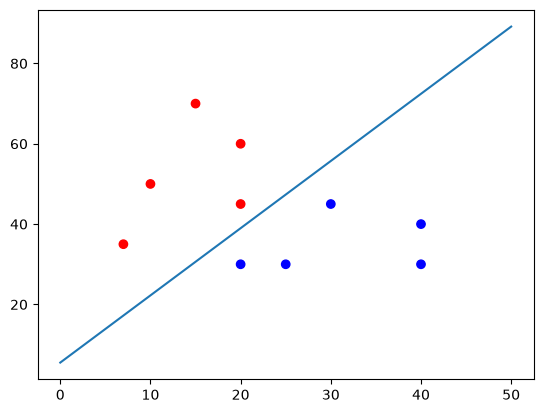

In [ ]:
plt.scatter(graph_x, graph_y, c=colors)

x = np.linspace(0, 50, 2)
y = -(w[1, 0] * x + w[0, 0]) / w[2, 0]
plt.plot(x, y)

Решение задачи бинарной классификации с помощью сигмоиды в качестве функции потерь и с использованием скорости забывания

In [ ]:
def sigmoid(w, x, y):
    return 2.0 / (1.0 + np.exp(np.dot(w, x) * y))

def sigmoid_derivative(w, x, y):
    e = np.exp(np.dot(w, x) * y)
    return -2.0 / ((1.0 + e) ** 2) * e * np.dot(x, y)

In [ ]:
data = []

with open("train.csv") as csv:
    while line := csv.readline():
        data.append(list(map(lambda x: x.strip(), line.split(";"))))

In [ ]:
graph_x, graph_y, colors = [], [], []
xs, ys = [], []

start_loss_sum = 0
w_start = np.array([0.0, 0.0])

In [ ]:
for x1, x2, name in data:
    y = 1.0 if name == "caterpillar" else -1.0

    x = np.array([float(x1), float(x2)])

    xs.append(x)
    ys.append(y)

    start_loss_sum += sigmoid(w_start, x, y)

    graph_x.append(int(x1))
    graph_y.append(int(x2))
    colors.append("red" if name == "caterpillar" else "blue")

In [ ]:
x = np.linspace(0, 50, 2)

from random import randint

In [ ]:
def solve(rate, decay, title=""):
    N = 500
    w = np.array([0.0, 0.0])

    quality = start_loss_sum / len(data)
    smoothed = [quality]
    true_q = [quality]

    for _ in range(N):
        i = randint(0, len(data) - 1)

        loss = sigmoid(w, xs[i], ys[i])
        w -= rate * sigmoid_derivative(w, xs[i], ys[i])
        quality = decay * loss + (1.0 - decay) * quality

        smoothed.append(quality)
        true_q.append(true_quality(w))

        if quality < 0.001:
            break

    plt.figure(figsize=(8, 4))
    plt.plot(smoothed, label=f"Q̄ (λ={decay})")
    plt.plot(true_q, label="true Q")
    plt.xlabel("iteration"); plt.ylabel("Q")
    plt.title(title)
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(5, 5))
    plt.scatter(graph_x, graph_y, c=colors)
    
    if abs(w[1]) > 1e-9:
        y = -(w[0] / w[1]) * x
        plt.plot(x, y, 'k')

    plt.title(title)
    plt.show()

In [ ]:
def true_quality(w):
    return np.mean([sigmoid(w, xs[i], ys[i]) for i in range(len(data))])

def solve2(rate, decay):
    N = 500
    w = np.array([0.0, 0.0])

    quality = start_loss_sum / len(data)
    smoothed = [quality]
    true_q = [quality]

    for _ in range(N):
        i1 = randint(0, len(data) - 1)
        i2 = randint(0, len(data) - 1)

        loss = 0.5 * (sigmoid(w, xs[i1], ys[i1]) + sigmoid(w, xs[i2], ys[i2]))
        grad = 0.5 * (sigmoid_derivative(w, xs[i1], ys[i1]) + sigmoid_derivative(w, xs[i2], ys[i2]))

        w -= rate * grad
        quality = decay * loss + (1.0 - decay) * quality

        smoothed.append(quality)
        true_q.append(true_quality(w))

        if quality < 0.001:
            break

    plt.figure(figsize=(8, 4))
    plt.plot(smoothed, label=f"Q̄ (batch=2, λ={decay})")
    plt.plot(true_q, label="true Q")
    plt.xlabel("iteration"); plt.ylabel("Q")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(5, 5))
    plt.scatter(graph_x, graph_y, c=colors)

    if abs(w[1]) > 1e-9:
        y = -(w[0] / w[1]) * x
        plt.plot(x, y, 'k')

    plt.show()

In [ ]:
def solve2(rate, decay, title=""):
    N = 500
    w = np.array([0.0, 0.0])

    quality = start_loss_sum / len(data)
    smoothed = [quality]
    true_q = [quality]

    for _ in range(N):
        i1 = randint(0, len(data) - 1)
        i2 = randint(0, len(data) - 1)

        loss = 0.5 * (sigmoid(w, xs[i1], ys[i1]) + sigmoid(w, xs[i2], ys[i2]))
        grad = 0.5 * (sigmoid_derivative(w, xs[i1], ys[i1]) + sigmoid_derivative(w, xs[i2], ys[i2]))

        w -= rate * grad
        quality = decay * loss + (1.0 - decay) * quality

        smoothed.append(quality)
        true_q.append(true_quality(w))

        if quality < 0.001:
            break

    plt.figure(figsize=(8, 4))
    plt.plot(smoothed, label=f"Q̄ (batch=2, λ={decay})")
    plt.plot(true_q, label="true Q")
    plt.xlabel("iteration"); plt.ylabel("Q")
    plt.title(title)
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(5, 5))
    plt.scatter(graph_x, graph_y, c=colors)

    if abs(w[1]) > 1e-9:
        y = -(w[0] / w[1]) * x
        plt.plot(x, y, 'k')

    plt.title(title)
    plt.show()

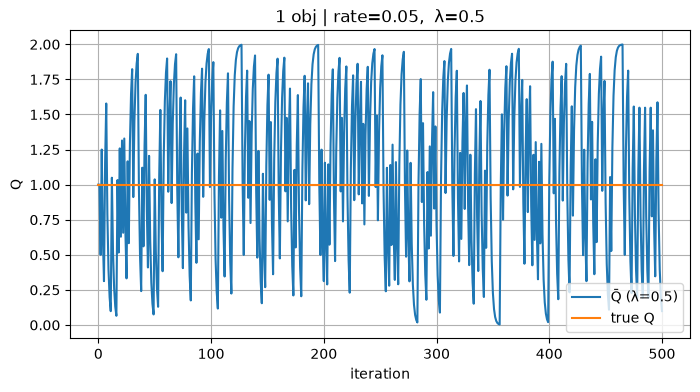

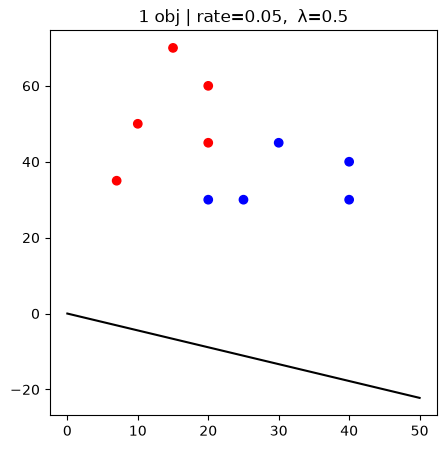

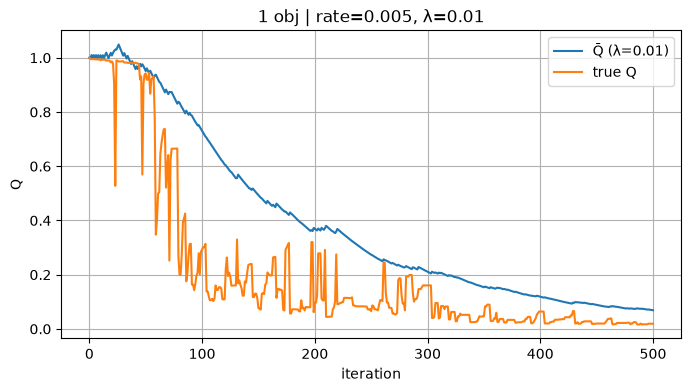

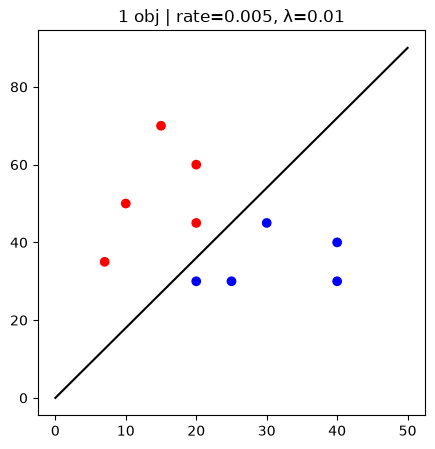

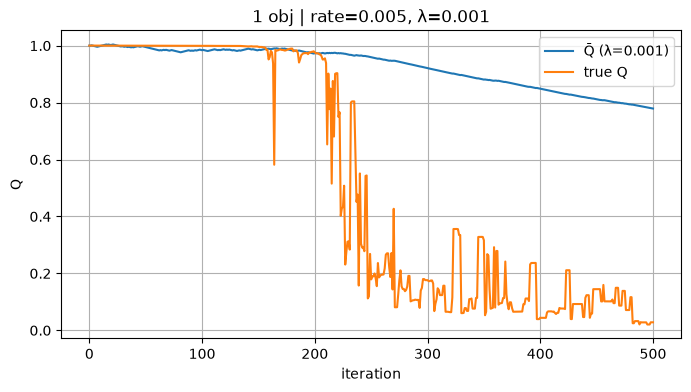

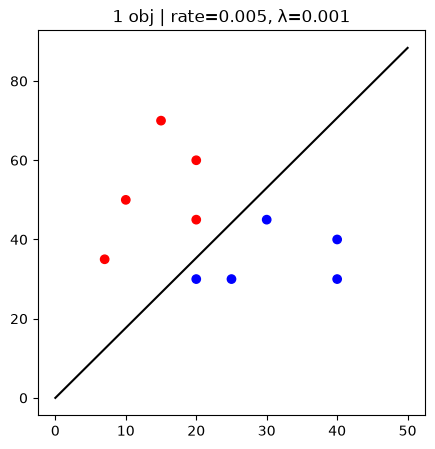

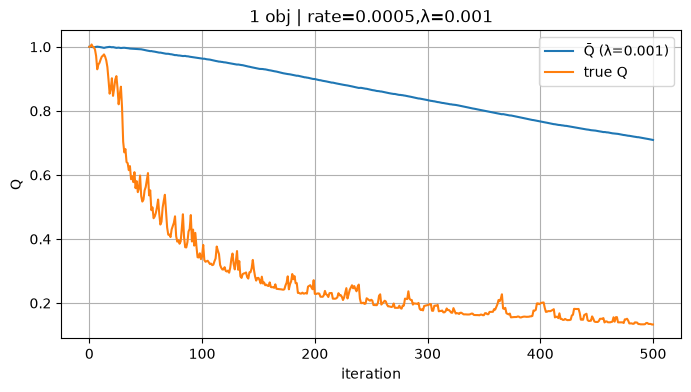

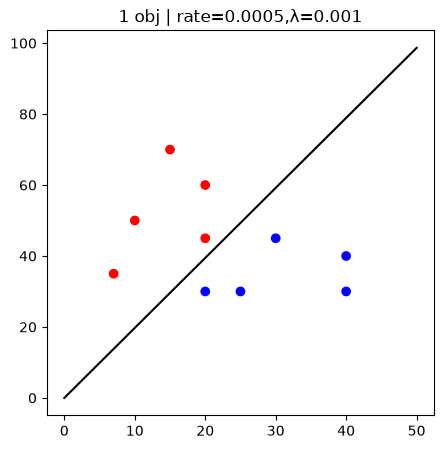

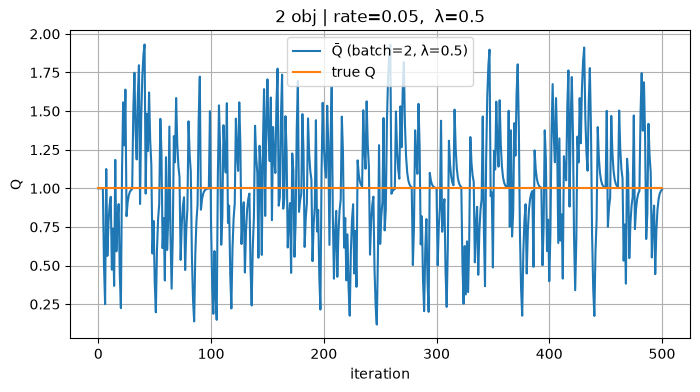

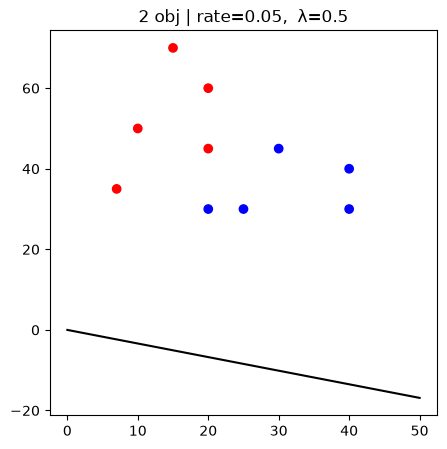

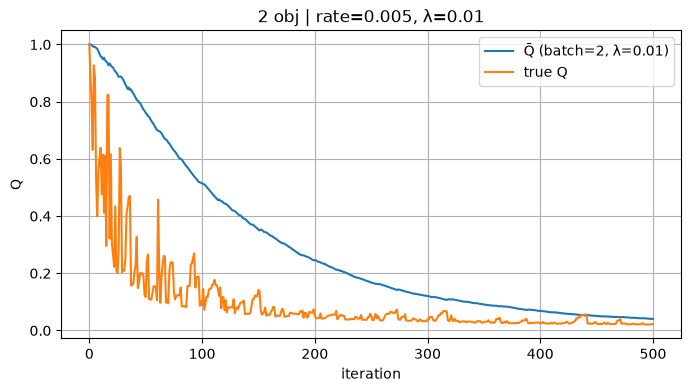

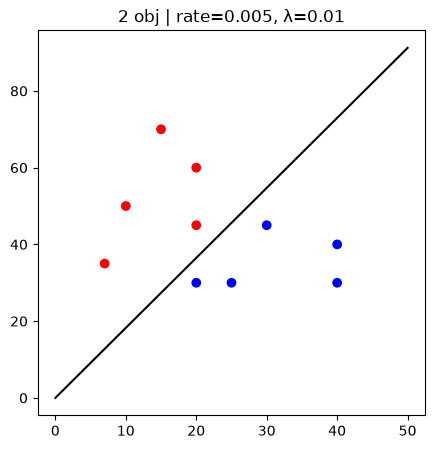

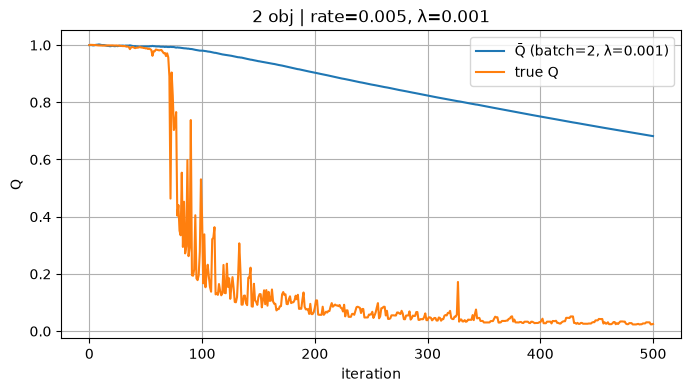

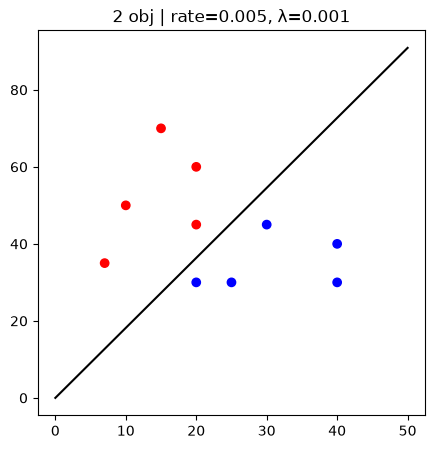

In [ ]:
np.random.seed(123456789)

solve(0.05, 0.5, "1 obj | rate=0.05,  λ=0.5")
solve(0.005, 0.01, "1 obj | rate=0.005, λ=0.01")
solve(0.005, 0.001, "1 obj | rate=0.005, λ=0.001")
solve(0.0005, 0.001, "1 obj | rate=0.0005,λ=0.001")

solve2(0.05, 0.5, "2 obj | rate=0.05,  λ=0.5")
solve2(0.005, 0.01, "2 obj | rate=0.005, λ=0.01")
solve2(0.005, 0.001, "2 obj | rate=0.005, λ=0.001")